In [ ]:
!pip install rasterio pillow matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 86.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import seaborn as sns
from PIL import Image
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter1d


In [ ]:
tiff_path = '/content/UHI_2024_Riyadh_RGB_Done.tif'  # 3-band RGB GeoTIFF
png_path = 'Riyadh_Governorate_thermometer.png'
jpg_path = 'Riyadh_Governorate_thermometer.jpg'

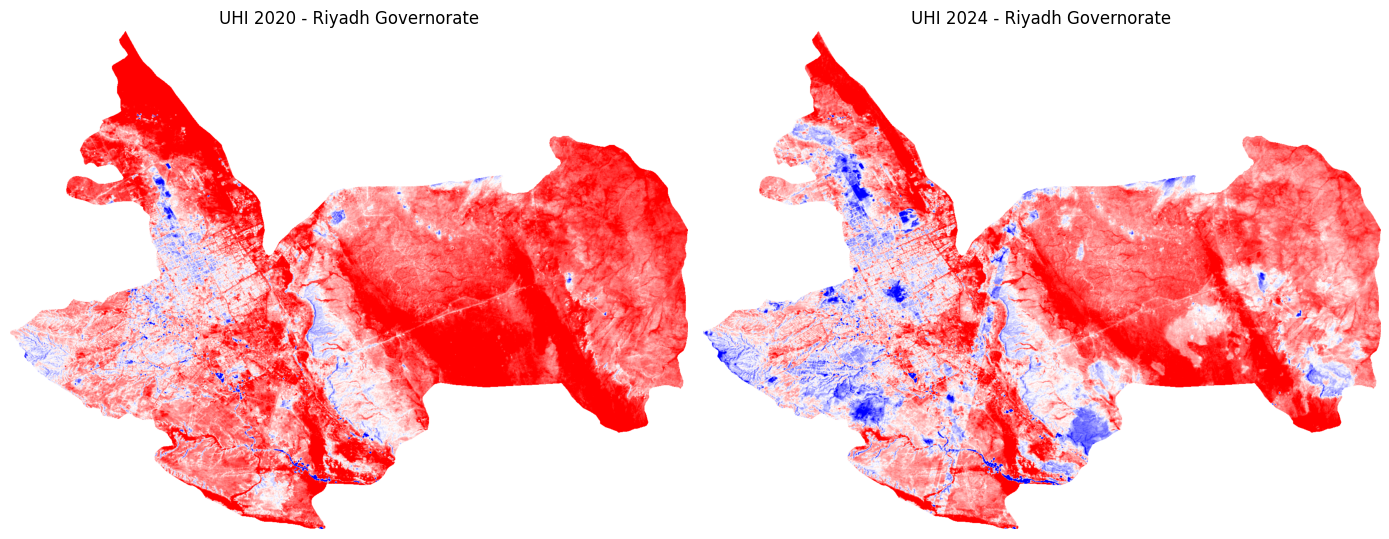

In [ ]:

def clean_rgb_tiff(tiff_path, out_png_path):
    with rasterio.open(tiff_path) as src:
        red = src.read(1)
        green = src.read(2)
        blue = src.read(3)

    rgb = np.stack([red, green, blue], axis=-1).astype(np.uint8)

    # Replace black (0,0,0) with white (255,255,255)
    black_mask = np.all(rgb == [0, 0, 0], axis=-1)
    rgb[black_mask] = [255, 255, 255]

    Image.fromarray(rgb).save(out_png_path)
    return rgb

def plot_side_by_side(img1, title1, img2, title2):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(img1)
    axes[0].set_title(title1)
    axes[0].axis('off')

    axes[1].imshow(img2)
    axes[1].set_title(title2)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    png_path = 'Riyadh_Governorate_UHI_combined.png'

# === File paths ===
tiff_2020 = '/content/UHI_2020_Riyadh_RGB_Governorate.tif'
tiff_2024 = '/content/UHI_2024_Riyadh_RGB_Done.tif'

png_2020 = 'Riyadh_Governorate_UHI_2020.png'
png_2024 = 'Riyadh_Governorate_UHI_2024.png'

# === Process and clean ===
img_2020 = clean_rgb_tiff(tiff_2020, png_2020)
img_2024 = clean_rgb_tiff(tiff_2024, png_2024)

# === Plot side by side ===
plot_side_by_side(img_2020, 'UHI 2020 - Riyadh Governorate', img_2024, 'UHI 2024 - Riyadh Governorate')


  system:index      LST_C label    year  \
0        0_0_0  48.008831  85°F  2015.0   
1        0_1_0  48.583059  86°F  2015.0   
2        0_2_0  50.433917  88°F  2015.0   
3        0_3_0  51.638769  92°F  2015.0   
4        1_0_0  51.117521  85°F  2016.0   

                                                .geo  
0  {"geodesic":false,"type":"Point","coordinates"...  
1  {"geodesic":false,"type":"Point","coordinates"...  
2  {"geodesic":false,"type":"Point","coordinates"...  
3  {"geodesic":false,"type":"Point","coordinates"...  
4  {"geodesic":false,"type":"Point","coordinates"...  


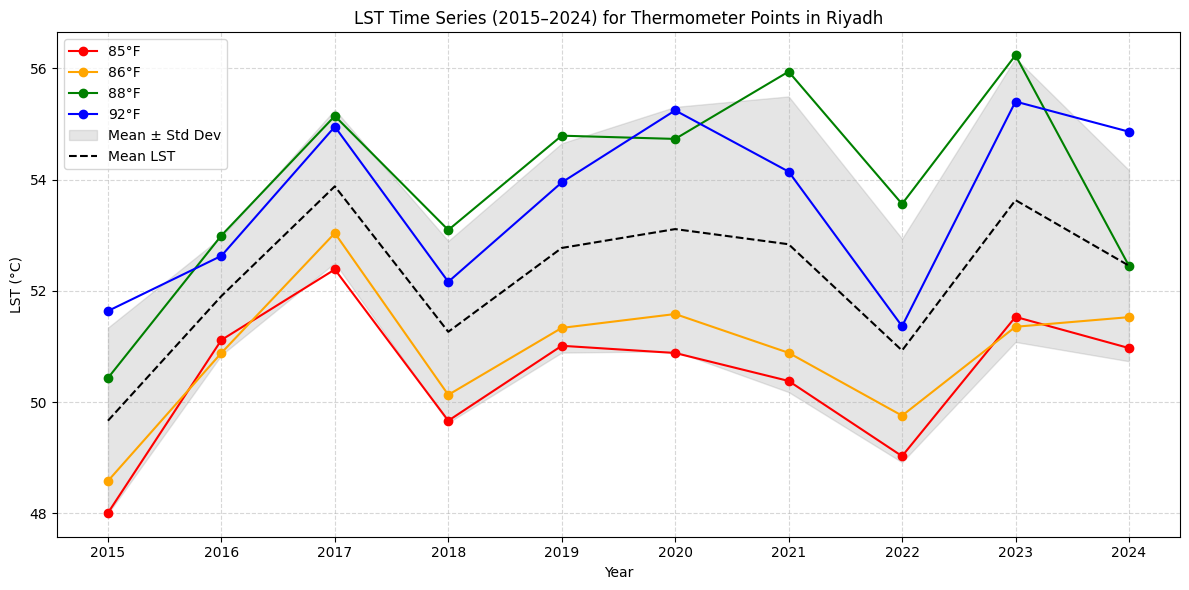

In [ ]:

# CSV path
csv_path = '/content/Thermometer_LST_Points_2015_2024.csv'

# Load the CSV
df = pd.read_csv(csv_path)

print(df.head())

# Group by point label
points = df['label'].unique()
colors = ['red', 'orange', 'green', 'blue']

# Pivot the data to make plotting easier
pivot_df = df.pivot(index='year', columns='label', values='LST_C')
years = pivot_df.index

# Compute mean & std across all thermometer points
mean_lst = pivot_df.mean(axis=1)
std_lst = pivot_df.std(axis=1)

# Plot
plt.figure(figsize=(12, 6))

# Plot each point's line
for i, label in enumerate(points):
    plt.plot(years, pivot_df[label], label=label, color=colors[i], marker='o')

# Add shaded region for mean ± std
plt.fill_between(years, mean_lst - std_lst, mean_lst + std_lst, color='gray', alpha=0.2, label='Mean ± Std Dev')

# Plot mean line
plt.plot(years, mean_lst, color='black', linestyle='--', label='Mean LST')

# Formatting
plt.title('LST Time Series (2015–2024) for Thermometer Points in Riyadh')
plt.xlabel('Year')
plt.ylabel('LST (°C)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(np.arange(2015, 2025, 1))
plt.legend()
plt.tight_layout()

# Save or show
plt.savefig('thermometer_LST_timeseries.png', dpi=300)
plt.show()


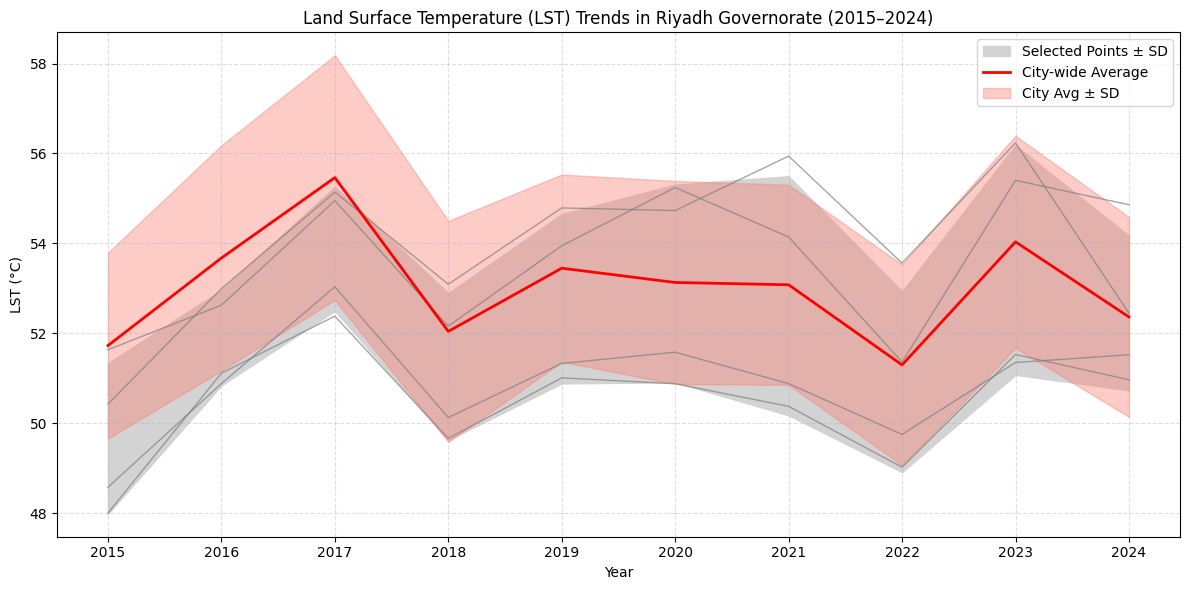

In [ ]:


# Load thermometer data
df_points = pd.read_csv('/content/Thermometer_LST_Points_2015_2024.csv')
pivot = df_points.pivot(index='year', columns='label', values='LST_C')
years = pivot.index

# Compute mean & std across thermometer points (gray envelope)
point_mean = pivot.mean(axis=1)
point_std = pivot.std(axis=1)

# Load city-wide average data (should contain 'year', 'mean', 'std' columns)
df_city = pd.read_csv('/content/City_Mean_LST_2015_2024.csv')

# Plot
plt.figure(figsize=(12, 6))

# Plot gray lines for selected points
for col in pivot.columns:
    plt.plot(years, pivot[col], color='gray', linewidth=1, alpha=0.7)

# Gray standard deviation envelope
plt.fill_between(years, point_mean - point_std, point_mean + point_std,
                 color='lightgray', label='Selected Points ± SD')

# Red city-wide mean
plt.plot(df_city['year'], df_city['mean'], color='red', linewidth=2, label='City-wide Average')

# Pale red envelope for city-wide std deviation
plt.fill_between(df_city['year'], df_city['mean'] - df_city['std'], df_city['mean'] + df_city['std'],
                 color='salmon', alpha=0.4, label='City Avg ± SD')

# Final formatting
plt.title('Land Surface Temperature (LST) Trends in Riyadh Governorate (2015–2024)')
plt.xlabel('Year')
plt.ylabel('LST (°C)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.xticks(np.arange(2015, 2025, 1))
plt.legend()
plt.tight_layout()

plt.savefig('Riyadh_LST_trends.png', dpi=300)
plt.show()


In [ ]:
# Load your file
df = pd.read_csv('/content/Riyadh_Governorate_UHI_TimeSeries_2015_2024.csv')
df.head()

,system:index,mean_rural,mean_urban,uhi,year,.geo
0,0,50.539910,49.903261,-0.636649,2015.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,1,51.580299,50.590778,-0.989521,2016.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,2,51.462821,52.634571,1.171750,2017.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,3,49.130335,49.082533,-0.047802,2018.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,4,50.631927,51.758516,1.126589,2019.0,"{""type"":""MultiPoint"",""coordinates"":[]}"


In [ ]:
df2 = pd.read_csv("/content/Thermometer_LST_Points_2015_2024.csv")
df2.head()

,system:index,LST_C,label,year,.geo
0,0_0_0,48.008831,85°F,2015.0,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
1,0_1_0,48.583059,86°F,2015.0,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
2,0_2_0,50.433917,88°F,2015.0,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
3,0_3_0,51.638769,92°F,2015.0,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
4,1_0_0,51.117521,85°F,2016.0,"{""geodesic"":false,""type"":""Point"",""coordinates""..."


In [ ]:
import pandas as pd

# Load thermometer UHI data
df = pd.read_csv('/content/Thermometer_UHI_2015_2024.csv')  # columns: year, label, UHI
df['year'] = df['year'].astype(int)

# Group by year and compute mean and std dev
city_uhi = df.groupby('year')['UHI'].agg(UHI_mean='mean', UHI_std='std').reset_index()

# Save to CSV
city_uhi.to_csv('city_uhi.csv', index=False)

print("city_uhi.csv created with columns: year, UHI_mean, UHI_std")
print(city_uhi.head())


✅ city_uhi.csv created with columns: year, UHI_mean, UHI_std
   year  UHI_mean   UHI_std
0  2015 -0.873774  1.673368
1  2016  0.326760  1.060755
2  2017  2.417305  1.377114
3  2018  2.133738  1.632533
4  2019  2.139941  1.881362


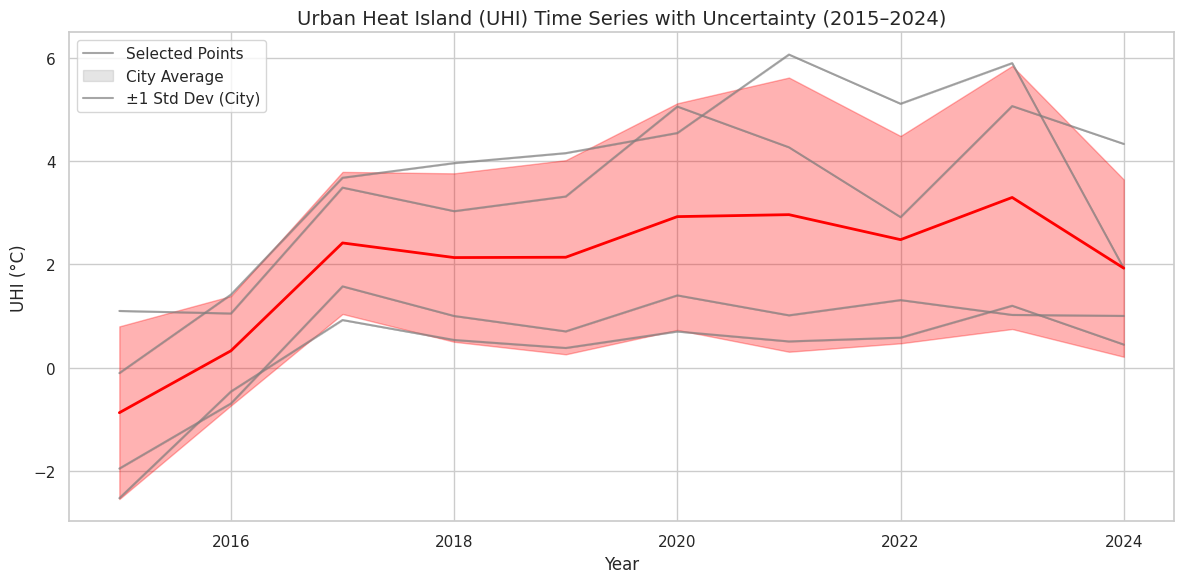

In [ ]:


# Load city-wide UHI average data
city_df = pd.read_csv('/content/city_uhi.csv')  # columns: year, UHI_mean, UHI_std
city_df['year'] = city_df['year'].astype(int)

# Load thermometer UHI data
thermo_df = pd.read_csv('/content/Thermometer_UHI_2015_2024.csv')  # columns: year, label, UHI
thermo_df['year'] = thermo_df['year'].astype(int)

# Set up plot
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

# Plot thermometer point trends (dark gray) and std shading (light gray)
for label, group in thermo_df.groupby('label'):
    mean = group.groupby('year')['UHI'].mean()
    std = group.groupby('year')['UHI'].std().fillna(0)
    years = mean.index

    plt.plot(years, mean.values, color='gray', alpha=0.7, label=None)
    plt.fill_between(years, mean - std, mean + std, color='gray', alpha=0.2)

# Plot city-wide average UHI with red uncertainty band
plt.plot(city_df['year'], city_df['UHI_mean'], color='red', linewidth=2, label='City Average')
plt.fill_between(city_df['year'],
                 city_df['UHI_mean'] - city_df['UHI_std'],
                 city_df['UHI_mean'] + city_df['UHI_std'],
                 color='red', alpha=0.3, label='±1 Std Dev (City)')

# Plotting
plt.title('Urban Heat Island (UHI) Time Series with Uncertainty (2015–2024)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('UHI (°C)')
plt.legend(['Selected Points', 'City Average', '±1 Std Dev (City)'], loc='upper left')
plt.tight_layout()
plt.show()


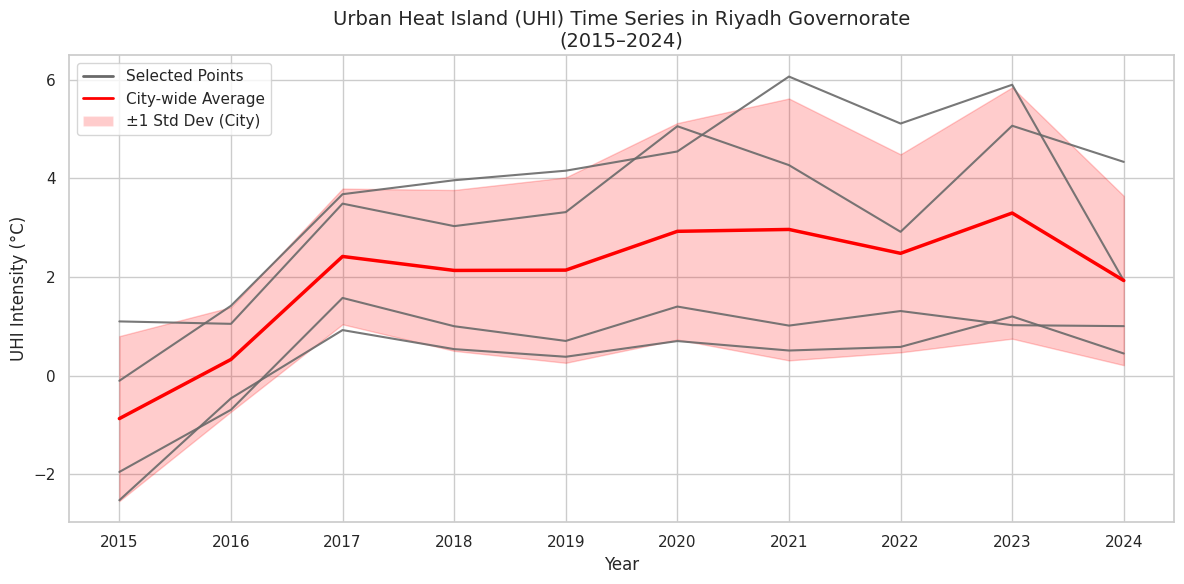

In [ ]:


# Load data
df_city = pd.read_csv('/content/city_uhi.csv')         # Columns: year, UHI_mean, UHI_std
df_thermo = pd.read_csv('/content/Thermometer_UHI_2015_2024.csv')  # Columns: year, label, UHI

# Plot setup
sns.set(style='whitegrid')
plt.figure(figsize=(12, 6))

# Plot thermometer points in dark gray
for label, group in df_thermo.groupby('label'):
    plt.plot(group['year'], group['UHI'], color='dimgray', alpha=0.9, linewidth=1.5)

# Plot city-wide average UHI with standard deviation
plt.plot(df_city['year'], df_city['UHI_mean'], color='red', linewidth=2.5)
plt.fill_between(df_city['year'],
                 df_city['UHI_mean'] - df_city['UHI_std'],
                 df_city['UHI_mean'] + df_city['UHI_std'],
                 color='red', alpha=0.2)

# Custom legend
custom_legend = [
    Line2D([0], [0], color='dimgray', lw=2, label='Selected Points'),
    Line2D([0], [0], color='red', lw=2, label='City-wide Average'),
    Patch(facecolor='red', alpha=0.2, label='±1 Std Dev (City)')
]

plt.legend(handles=custom_legend, loc='upper left')

# Labels & formatting
plt.xlabel('Year')
plt.ylabel('UHI Intensity (°C)')
plt.title('Urban Heat Island (UHI) Time Series in Riyadh Governorate\n(2015–2024)', fontsize=14)
plt.xticks(df_city['year'])
plt.tight_layout()

# Save and show
plt.savefig('uhi_timeseries_with_legend.png', dpi=300)
plt.show()


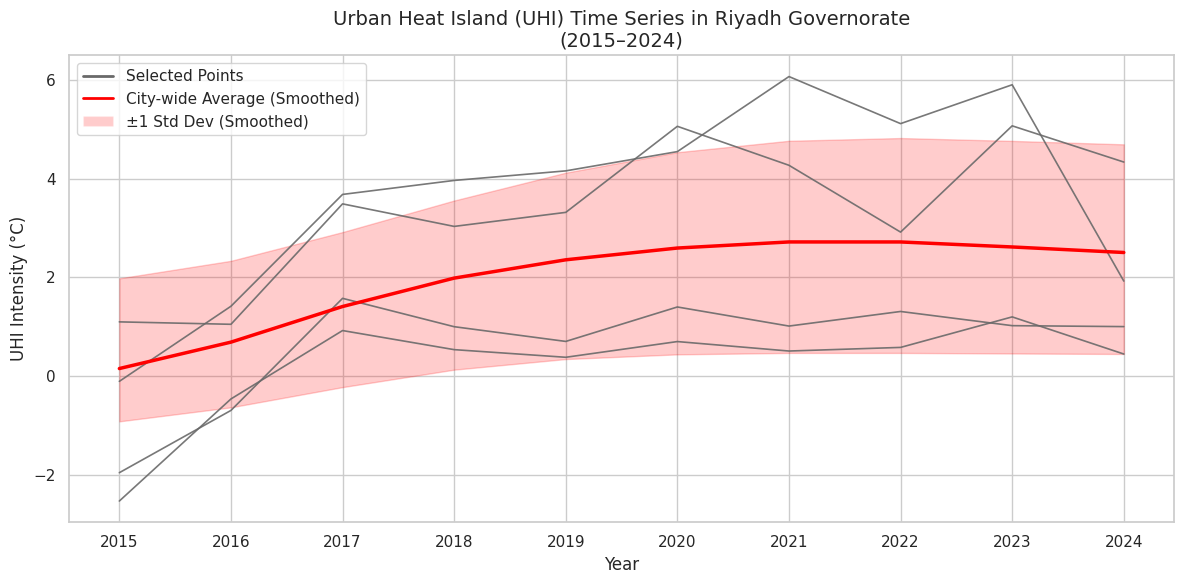

In [ ]:

# Load data
df_city = pd.read_csv('/content/city_uhi.csv')  # Columns: year, UHI_mean, UHI_std
df_thermo = pd.read_csv('/content/Thermometer_UHI_2015_2024.csv')  # Columns: year, label, UHI

# Sort to ensure correct order for smoothing
df_city = df_city.sort_values(by='year')
years = df_city['year'].values
mean_uhi = df_city['UHI_mean'].values
std_uhi = df_city['UHI_std'].values

# Apply Gaussian smoothing
sigma_main = 1.5
sigma_std = 2.0

mean_uhi_smooth = gaussian_filter1d(mean_uhi, sigma=sigma_main)
upper_bound = gaussian_filter1d(mean_uhi + std_uhi, sigma=sigma_std)
lower_bound = gaussian_filter1d(mean_uhi - std_uhi, sigma=sigma_std)

# Plot setup
sns.set(style='whitegrid')
plt.figure(figsize=(12, 6))

# Plot thermometer points in dark gray
for label, group in df_thermo.groupby('label'):
    plt.plot(group['year'], group['UHI'], color='dimgray', alpha=0.9, linewidth=1.2)

# Plot smoothed city-wide average and uncertainty band
plt.plot(years, mean_uhi_smooth, color='red', linewidth=2.5)
plt.fill_between(years, lower_bound, upper_bound, color='red', alpha=0.2)

# Custom legend
custom_legend = [
    Line2D([0], [0], color='dimgray', lw=2, label='Selected Points'),
    Line2D([0], [0], color='red', lw=2, label='City-wide Average (Smoothed)'),
    Patch(facecolor='red', alpha=0.2, label='±1 Std Dev (Smoothed)')
]

plt.legend(handles=custom_legend, loc='upper left')

# Labels & formatting
plt.xlabel('Year')
plt.ylabel('UHI Intensity (°C)')
plt.title('Urban Heat Island (UHI) Time Series in Riyadh Governorate\n(2015–2024)', fontsize=14)
plt.xticks(years)
plt.tight_layout()

# Save and show
plt.savefig('uhi_timeseries_smoothed.png', dpi=300)
plt.show()


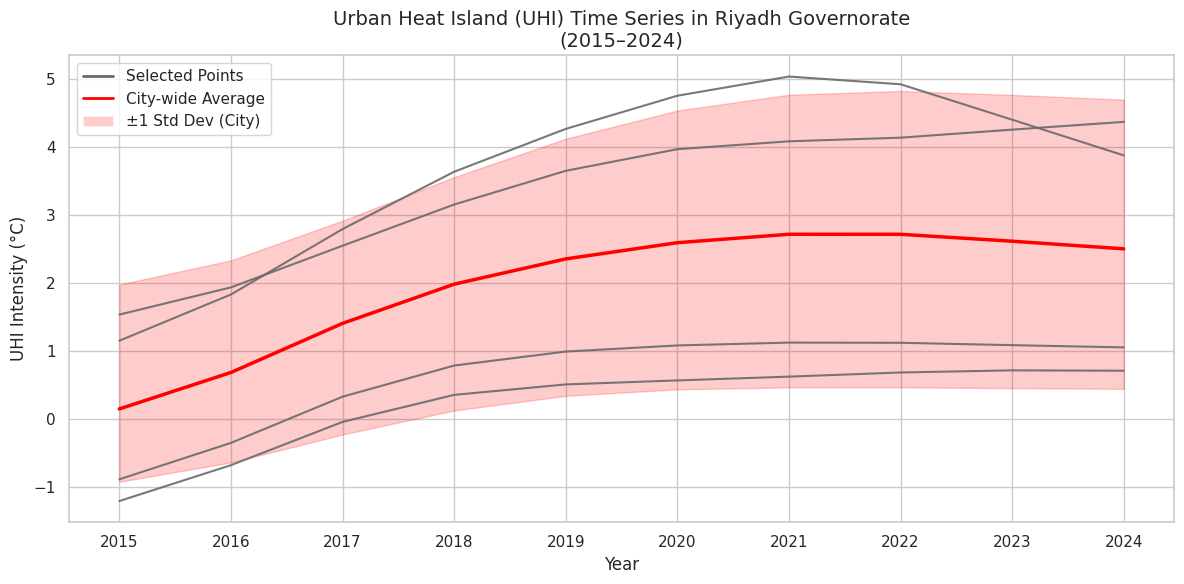

In [ ]:


# Load data
df_city = pd.read_csv('/content/city_uhi.csv')  # Columns: year, UHI_mean, UHI_std
df_thermo = pd.read_csv('/content/Thermometer_UHI_2015_2024.csv')  # Columns: year, label, UHI

# Sort city-wide data by year
df_city = df_city.sort_values(by='year')
years = df_city['year'].values
mean_uhi = df_city['UHI_mean'].values
std_uhi = df_city['UHI_std'].values

# Apply Gaussian smoothing to city-wide data
sigma_main = 1.5
sigma_std = 2.0

mean_uhi_smooth = gaussian_filter1d(mean_uhi, sigma=sigma_main)
upper_bound = gaussian_filter1d(mean_uhi + std_uhi, sigma=sigma_std)
lower_bound = gaussian_filter1d(mean_uhi - std_uhi, sigma=sigma_std)

# Plot setup
sns.set(style='whitegrid')
plt.figure(figsize=(12, 6))

# --- Plot smoothed thermometer point lines ---
for label, group in df_thermo.groupby('label'):
    group = group.sort_values(by='year')
    smoothed_uhi = gaussian_filter1d(group['UHI'].values, sigma=1.5)
    plt.plot(group['year'].values, smoothed_uhi, color='dimgray', alpha=0.9, linewidth=1.5)

# --- Plot smoothed city-wide average and uncertainty band ---
plt.plot(years, mean_uhi_smooth, color='red', linewidth=2.5)
plt.fill_between(years, lower_bound, upper_bound, color='red', alpha=0.2)

# --- Custom legend ---
custom_legend = [
    Line2D([0], [0], color='dimgray', lw=2, label='Selected Points'),
    Line2D([0], [0], color='red', lw=2, label='City-wide Average'),
    Patch(facecolor='red', alpha=0.2, label='±1 Std Dev (City)')
]

plt.legend(handles=custom_legend, loc='upper left')

# --- Labels & formatting ---
plt.xlabel('Year')
plt.ylabel('UHI Intensity (°C)')
plt.title('Urban Heat Island (UHI) Time Series in Riyadh Governorate\n(2015–2024)', fontsize=14)
plt.xticks(years)
plt.tight_layout()

# Save and show
plt.savefig('uhi_timeseries_smoothed_all.png', dpi=300)
plt.show()


In [ ]:
!pip install contextily


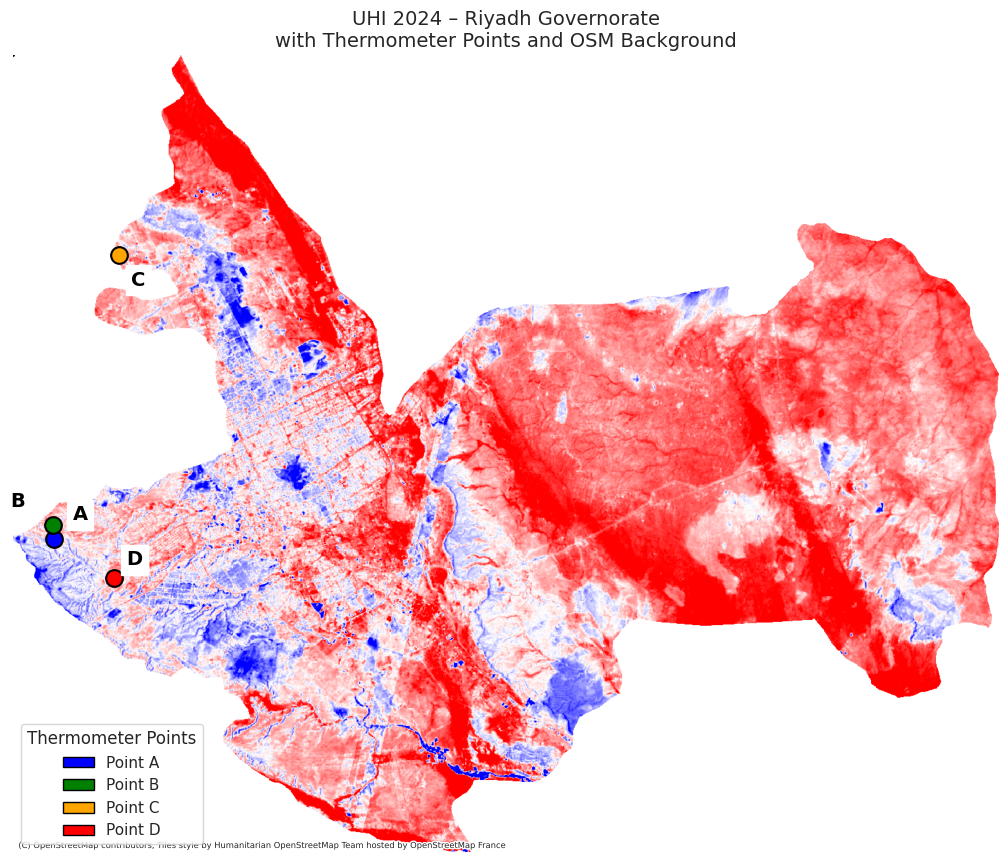

In [ ]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import contextily as ctx
from shapely.geometry import box
from pyproj import Transformer

import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx
from matplotlib.lines import Line2D

# File paths
tiff_path = '/content/UHI_2024_Riyadh_RGB_Done.tif'
png_path = 'UHI_2024_Riyadh_with_OSM_Final.png'

# --- Step 1: Reproject the image to EPSG:3857 ---
with rasterio.open(tiff_path) as src:
    transform, width, height = calculate_default_transform(
        src.crs, 'EPSG:3857', src.width, src.height, *src.bounds)
    kwargs = src.meta.copy()
    kwargs.update({
        'crs': 'EPSG:3857',
        'transform': transform,
        'width': width,
        'height': height
    })

    red = np.empty((height, width), dtype=np.uint8)
    green = np.empty((height, width), dtype=np.uint8)
    blue = np.empty((height, width), dtype=np.uint8)

    reproject(src.read(1), red, src_transform=src.transform, src_crs=src.crs,
              dst_transform=transform, dst_crs='EPSG:3857', resampling=Resampling.nearest)
    reproject(src.read(2), green, src_transform=src.transform, src_crs=src.crs,
              dst_transform=transform, dst_crs='EPSG:3857', resampling=Resampling.nearest)
    reproject(src.read(3), blue, src_transform=src.transform, src_crs=src.crs,
              dst_transform=transform, dst_crs='EPSG:3857', resampling=Resampling.nearest)

rgb = np.stack([red, green, blue], axis=-1)
rgb[np.all(rgb == [0, 0, 0], axis=-1)] = [255, 255, 255]  # Make background white

# Get extent
left, bottom = transform * (0, height)
right, top = transform * (width, 0)
extent_3857 = [left, right, bottom, top]

# --- Step 2: Reproject thermometer points ---
transformer = Transformer.from_crs('EPSG:4326', 'EPSG:3857', always_xy=True)
points_wgs = [
    (46.3749, 24.6324, 'A', 'blue', 3000, 3000),
    (46.3741, 24.6502, 'B', 'green', -7000, 3000),
    (46.4689, 25.0059, 'C', 'orange', 2000, -5000),
    (46.4618, 24.5813, 'D', 'red', 2000, 2000)
]
points_3857 = [(transformer.transform(lon, lat)[0], transformer.transform(lon, lat)[1], label, color, dx, dy)
               for lon, lat, label, color, dx, dy in points_wgs]

# --- Step 3: Plot with OSM Basemap ---
fig, ax = plt.subplots(figsize=(10.24, 10.24))  # 26x26 cm

# Set extent for contextily
ax.set_xlim(extent_3857[0], extent_3857[1])
ax.set_ylim(extent_3857[2], extent_3857[3])

# Add basemap BELOW
ctx.add_basemap(ax, crs='EPSG:3857', source=ctx.providers.OpenStreetMap.HOT, attribution_size=6)

# Plot UHI on top
ax.imshow(rgb, extent=extent_3857)

# Add thermometer points
for x, y, label, color, dx, dy in points_3857:
    ax.plot(x, y, marker='o', markersize=12, markerfacecolor=color,
            markeredgecolor='black', markeredgewidth=1.5)
    ax.text(x + dx, y + dy, label, fontsize=14, fontweight='bold',
            color='black', backgroundcolor='white')

# Draw outline
outline = box(*extent_3857)
ax.plot(*outline.exterior.xy, color='black', linewidth=2)

# Legend
legend_handles = [
    Patch(facecolor=color, edgecolor='black', label=f'Point {label}')
    for _, _, label, color, _, _ in points_3857
]
ax.legend(handles=legend_handles, loc='lower left', fontsize=11, title='Thermometer Points')

# Final touches
ax.set_title("UHI 2024 – Riyadh Governorate\nwith Thermometer Points and OSM Background", fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.savefig(png_path, dpi=300)
plt.show()


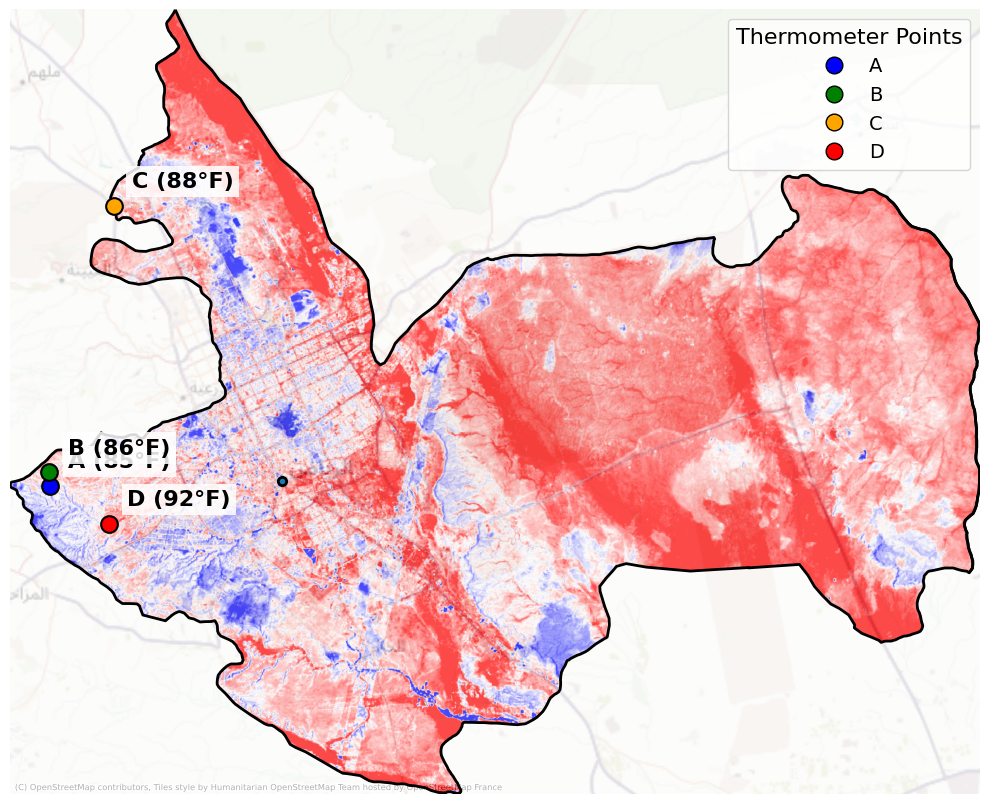

In [ ]:


# Load raster and reproject to EPSG:3857 (Web Mercator)
tiff_path = '/content/UHI_2024_Riyadh_RGB_Done.tif'
with rasterio.open(tiff_path) as src:
    red = src.read(1)
    green = src.read(2)
    blue = src.read(3)
    src_crs = src.crs

    dst_crs = 'EPSG:3857'
    transform, width, height = rasterio.warp.calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds)

    red_merc = np.empty((height, width), dtype=red.dtype)
    green_merc = np.empty((height, width), dtype=green.dtype)
    blue_merc = np.empty((height, width), dtype=blue.dtype)

    rasterio.warp.reproject(
        source=red, destination=red_merc,
        src_transform=src.transform, src_crs=src_crs,
        dst_transform=transform, dst_crs=dst_crs,
        resampling=rasterio.enums.Resampling.nearest)
    rasterio.warp.reproject(
        source=green, destination=green_merc,
        src_transform=src.transform, src_crs=src_crs,
        dst_transform=transform, dst_crs=dst_crs,
        resampling=rasterio.enums.Resampling.nearest)
    rasterio.warp.reproject(
        source=blue, destination=blue_merc,
        src_transform=src.transform, src_crs=src_crs,
        dst_transform=transform, dst_crs=dst_crs,
        resampling=rasterio.enums.Resampling.nearest)

rgb = np.stack([red_merc, green_merc, blue_merc], axis=-1)

# Replace black pixels with white background
black_mask = np.all(rgb == 0, axis=-1)
rgb[black_mask] = 255

# Thermometer points with colors and temps
points_lonlat = [
    (46.3749, 24.6324, 'A', 'blue', '85°F'),
    (46.3741, 24.6502, 'B', 'green', '86°F'),
    (46.4689, 25.0059, 'C', 'orange', '88°F'),
    (46.4618, 24.5813, 'D', 'red', '92°F')
]

gdf_points = gpd.GeoDataFrame(
    {'label': [p[2] for p in points_lonlat],
     'color': [p[3] for p in points_lonlat],
     'temp': [p[4] for p in points_lonlat]},
    geometry=[Point(p[0], p[1]) for p in points_lonlat],
    crs='EPSG:4326'
)

gdf_points = gdf_points.to_crs(dst_crs)

# Load Riyadh Governorate boundary (replace path with your boundary file)
boundary_path = '/content/Riyadh_governate.geojson'
gdf_boundary = gpd.read_file(boundary_path).to_crs(dst_crs)

xmin = transform[2]
xmax = transform[2] + transform[0] * width
ymax = transform[5]
ymin = transform[5] + transform[4] * height
extent = [xmin, xmax, ymin, ymax]

fig, ax = plt.subplots(figsize=(10, 10))  # 26cm x 26cm approx

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# Add sharper basemap with stronger style and higher zoom
#ctx.add_basemap(ax, crs=dst_crs, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.8, zoom=13)
#ctx.add_basemap(ax, crs=dst_crs, source=ctx.providers.CartoDB.DarkMatter, alpha=0.8, zoom=13)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.HOT, attribution_size=6)



# Overlay UHI raster with some transparency
ax.imshow(rgb, extent=extent, alpha=0.7, zorder=5)

# Plot Riyadh boundary with black edge and transparent fill
gdf_boundary.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=2, zorder=20)

# Plot points with colors and black edges
for _, row in gdf_points.iterrows():
    ax.plot(row.geometry.x, row.geometry.y, 'o',
            markersize=12,
            markerfacecolor=row['color'],
            markeredgecolor='black',
            markeredgewidth=1.5,
            zorder=25)
    ax.text(row.geometry.x + 3000, row.geometry.y + 3000,
            f"{row['label']} ({row['temp']})",
            fontsize=16, fontweight='bold',
            color='black',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.85),
            zorder=30)

# Legend shows only A-D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=row['label'],
           markerfacecolor=row['color'], markeredgecolor='black', markersize=12)
    for _, row in gdf_points.iterrows()
]

ax.legend(handles=legend_elements, loc='upper right', fontsize=14, title='Thermometer Points', title_fontsize=16)

ax.axis('off')

plt.tight_layout()

# Save figure as PNG with high DPI
plt.savefig('Riyadh_UHI_Map_with_Boundary1.png', dpi=300)

plt.show()


In [ ]:
import contextily as ctx
print(ctx.__version__)


1.6.2


In [ ]:
! pip install --upgrade contextily


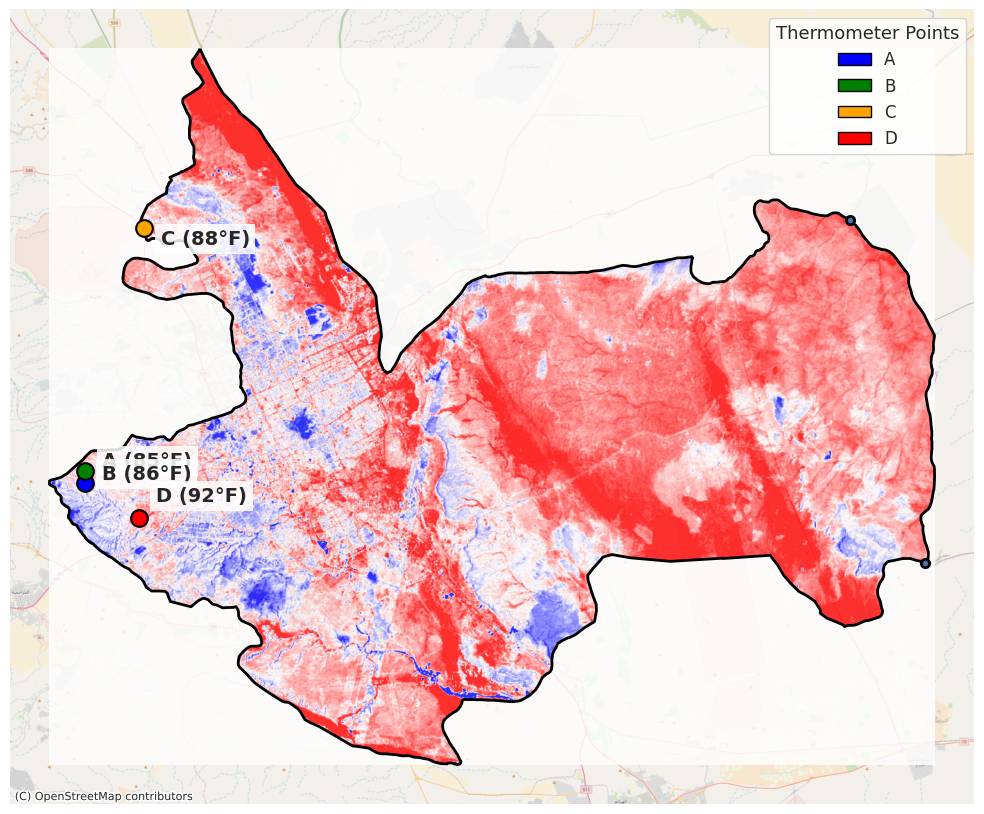

In [ ]:
# File paths
tiff_path = '/content/UHI_2024_Riyadh_RGB_Done.tif'
geojson_path = '/content/Riyadh_governate.geojson'  # Update the path if needed


png_path = 'Riyadh_UHI_Basemap_Buffer.png'

# Step 1: Load and reproject raster to EPSG:3857
with rasterio.open(tiff_path) as src:
    red = src.read(1)
    green = src.read(2)
    blue = src.read(3)
    src_crs = src.crs
    dst_crs = 'EPSG:3857'

    transform, width, height = calculate_default_transform(
        src_crs, dst_crs, src.width, src.height, *src.bounds)

    kwargs = src.meta.copy()
    kwargs.update({
        'crs': dst_crs,
        'transform': transform,
        'width': width,
        'height': height
    })

    # Prepare arrays and reproject
    red_merc = np.empty((height, width), dtype=red.dtype)
    green_merc = np.empty((height, width), dtype=green.dtype)
    blue_merc = np.empty((height, width), dtype=blue.dtype)

    for src_band, dest_band in zip([red, green, blue], [red_merc, green_merc, blue_merc]):
        reproject(
            source=src_band,
            destination=dest_band,
            src_transform=src.transform,
            src_crs=src_crs,
            dst_transform=transform,
            dst_crs=dst_crs,
            resampling=Resampling.nearest
        )

# Stack RGB and clean black
rgb = np.stack([red_merc, green_merc, blue_merc], axis=-1)
rgb[np.all(rgb == 0, axis=-1)] = 255

# Step 2: Define extent and apply buffer
xmin, xmax = transform[2], transform[2] + width * transform[0]
ymax, ymin = transform[5], transform[5] + height * transform[4]
#buffer = 7000  # 15 km buffer
#extent = [xmin - buffer, xmax + buffer, ymin - buffer, ymax + buffer]

extent = [xmin, xmax, ymin, ymax]

# Set buffer
buffer = 7000  # 15 km buffer

# Axis limits with buffer
ax.set_xlim(xmin - buffer, xmax + buffer)
ax.set_ylim(ymin - buffer, ymax + buffer)


# Step 3: Load thermometer points and reproject
points = [
    (46.3749, 24.6324, 'A', 'blue', '85°F'),
    (46.3741, 24.6502, 'B', 'green', '86°F'),
    (46.4689, 25.0059, 'C', 'orange', '88°F'),
    (46.4618, 24.5813, 'D', 'red', '92°F')
]
gdf_points = gpd.GeoDataFrame(
    {'label': [p[2] for p in points], 'color': [p[3] for p in points], 'temp': [p[4] for p in points]},
    geometry=[Point(p[0], p[1]) for p in points],
    crs='EPSG:4326'
).to_crs(dst_crs)

# Step 4: Load Riyadh boundary and reproject
gdf_border = gpd.read_file(geojson_path).to_crs(dst_crs)

# Step 5: Plot
#fig, ax = plt.subplots(figsize=(10, 10))  # ~26cm x 26cm
fig, ax = plt.subplots(figsize=(10, 10)) # 26cm x 26cm approx

# Axis limits with buffer
ax.set_xlim(xmin - buffer, xmax + buffer)
ax.set_ylim(ymin - buffer, ymax + buffer)


# Set buffered extent
#ax.set_xlim(extent[0], extent[1])
#ax.set_ylim(extent[2], extent[3])

# White background
ax.imshow(np.ones((10, 10, 3)), extent=extent, zorder=0, alpha=1.0)

# Basemap underneath
ctx.add_basemap(ax, crs=dst_crs, source=ctx.providers.OpenStreetMap.Mapnik, zoom=11, alpha=0.9, zorder=1)

# UHI RGB image in original extent
ax.imshow(rgb, extent=(xmin, xmax, ymin, ymax), alpha=0.8, zorder=2)

# Riyadh border on top
gdf_border.boundary.plot(ax=ax, edgecolor='black', linewidth=2, zorder=3)

# Plot thermometer points with label + F temp
# Plot thermometer points with label + F temp
for _, row in gdf_points.iterrows():
    x, y = row.geometry.x, row.geometry.y

    # Custom offset logic per point
    if row['label'] == 'A':
        dx, dy = 3000, 3000
    elif row['label'] == 'B':
        dx, dy = 3000, -1500  # Lower to avoid overlapping with A
    elif row['label'] == 'C':
        dx, dy = 3000, -3000
    elif row['label'] == 'D':
        dx, dy = 3000, 3000
    else:
        dx, dy = 3000, 3000  # default offset

    # Plot point
    ax.plot(x, y, 'o', markersize=12, markerfacecolor=row['color'],
            markeredgecolor='black', markeredgewidth=1.5, zorder=4)

    # Plot label with F temp
    ax.text(x + dx, y + dy, f"{row['label']} ({row['temp']})",
            fontsize=14, fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.85),
            zorder=5)

# Custom legend
legend_patches = [
    Patch(facecolor=row['color'], edgecolor='black', label=row['label'])
    for _, row in gdf_points.iterrows()
]
ax.legend(handles=legend_patches, loc='upper right', title="Thermometer Points",
          fontsize=12, title_fontsize=13)

# Clean format
ax.axis('off')
plt.tight_layout()

# Save output
plt.savefig(png_path, dpi=300)
plt.show()
